# Notebook 1 — Exploratory Data Analysis
Supply Chain Disruption Prediction System — India

In [1]:
# ── CELL 1: Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── CELL 2: Load all 4 CSVs ───────────────────────────────────────────────────
# CHANGE THESE PATHS if your datasets folder is in a different location
DATA_DIR = '../datasets/'

d1 = pd.read_csv(DATA_DIR + 'dataset1_supply_chain_india.csv', parse_dates=['order_date'])
d3 = pd.read_csv(DATA_DIR + 'dataset3_news_sentiment_india.csv', parse_dates=['date'])
d4 = pd.read_csv(DATA_DIR + 'dataset4_supplier_risk_india.csv')
d5 = pd.read_csv(DATA_DIR + 'dataset5_historical_disruptions_india.csv', parse_dates=['event_date'])

print(f'D1 shape: {d1.shape}')
print(f'D3 shape: {d3.shape}')
print(f'D4 shape: {d4.shape}')
print(f'D5 shape: {d5.shape}')

D1 shape: (2000, 15)
D3 shape: (600, 8)
D4 shape: (60, 10)
D5 shape: (1500, 10)


In [3]:
# ── CELL 3: Basic info for each dataset ──────────────────────────────────────
for name, df in [('D1 Supply Chain', d1), ('D3 News Sentiment', d3),
                  ('D4 Supplier Risk', d4), ('D5 Historical Disruptions', d5)]:
    print(f'\n{'='*50}')
    print(f'{name}')
    print(f'  Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
    print(f'  Missing values:\n{df.isnull().sum()[df.isnull().sum()>0]}')
    print(f'  Duplicates: {df.duplicated().sum()}')


D1 Supply Chain
  Rows: 2000  |  Columns: 15
  Missing values:
disruption_cause    991
dtype: int64
  Duplicates: 0

D3 News Sentiment
  Rows: 600  |  Columns: 8
  Missing values:
Series([], dtype: int64)
  Duplicates: 0

D4 Supplier Risk
  Rows: 60  |  Columns: 10
  Missing values:
Series([], dtype: int64)
  Duplicates: 0

D5 Historical Disruptions
  Rows: 1500  |  Columns: 10
  Missing values:
disruption_type    129
dtype: int64
  Duplicates: 0


In [4]:
# ── CELL 4: D1 data types and head ───────────────────────────────────────────
print('D1 dtypes:')
print(d1.dtypes)
d1.head()

D1 dtypes:
order_id                             str
order_date                datetime64[us]
supplier_name                        str
supplier_city                        str
destination_city                     str
product_category                     str
transport_mode                       str
distance_km                        int64
promised_delivery_days             int64
actual_delivery_days               int64
delay_days                         int64
shipment_cost_inr                float64
quantity_units                     int64
disruption_cause                     str
disruption_label                   int64
dtype: object


,order_id,order_date,supplier_name,supplier_city,destination_city,product_category,transport_mode,distance_km,promised_delivery_days,actual_delivery_days,delay_days,shipment_cost_inr,quantity_units,disruption_cause,disruption_label
0,ORD00001,2022-10-17,ONGC Supplies,Kolkata,Chennai,Agricultural Goods,Road,619,4,14,10,48034.72,3466,Heavy Rainfall,1
1,ORD00002,2021-02-02,BHEL Components,Jaipur,Surat,Textiles,Road,308,3,13,10,359429.71,4474,Political Unrest,1
2,ORD00003,2022-03-06,Steel Authority India,Nagpur,Bhopal,Pharmaceuticals,Road+Rail,226,6,6,0,350579.00,2797,NaN,0
3,ORD00004,2021-10-12,Wipro Procurement,Delhi,Ahmedabad,Industrial Machinery,Rail,596,5,11,6,303844.39,365,Accident,1
4,ORD00005,2023-01-18,NTPC Materials,Jaipur,Bangalore,Industrial Machinery,Road,2774,10,8,0,290789.31,579,NaN,0


In [5]:
# ── CELL 5: D1 statistics ────────────────────────────────────────────────────
d1.describe()

,order_date,distance_km,promised_delivery_days,actual_delivery_days,delay_days,shipment_cost_inr,quantity_units,disruption_label
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2022-05-10 15:39:36,1499.945500,8.997500,16.350000,7.530500,250969.700110,2479.723000,0.504500
min,2021-01-01 00:00:00,201.000000,3.000000,1.000000,0.000000,5017.680000,12.000000,0.000000
25%,2021-09-02 00:00:00,868.000000,6.000000,11.000000,2.000000,123470.085000,1176.000000,0.000000
50%,2022-04-30 00:00:00,1488.000000,9.000000,16.000000,6.000000,253777.540000,2521.000000,1.000000
75%,2023-01-23 00:00:00,2146.000000,12.000000,22.000000,13.000000,374849.360000,3652.000000,1.000000
max,2023-09-28 00:00:00,2797.000000,15.000000,35.000000,20.000000,499977.320000,4989.000000,1.000000
std,NaN,739.893323,3.745866,7.605223,6.387838,143520.185714,1434.757855,0.500105


In [6]:
# ── CELL 6: Open-Meteo API — sample weather fetch for EDA (Mumbai) ───────────
url = 'https://archive-api.open-meteo.com/v1/archive'
params = {
    'latitude': 19.08,
    'longitude': 72.88,
    'start_date': '2024-01-01',
    'end_date': '2024-01-31',
    'daily': 'precipitation_sum,temperature_2m_max,wind_speed_10m_max',
    'timezone': 'Asia/Kolkata'
}
resp = requests.get(url, params=params, timeout=30)
weather_sample = pd.DataFrame(resp.json()['daily'])
weather_sample.rename(columns={
    'time': 'date',
    'precipitation_sum': 'rainfall_mm',
    'temperature_2m_max': 'temperature_celsius',
    'wind_speed_10m_max': 'wind_speed_kmh'
}, inplace=True)
print('Weather API sample — Mumbai Jan 2024:')
weather_sample.head()

Weather API sample — Mumbai Jan 2024:


,date,rainfall_mm,temperature_celsius,wind_speed_kmh
0,2024-01-01,0.0,31.6,15.9
1,2024-01-02,0.0,31.0,20.0
2,2024-01-03,0.0,30.1,18.7
3,2024-01-04,0.0,28.9,18.6
4,2024-01-05,0.0,29.8,17.6


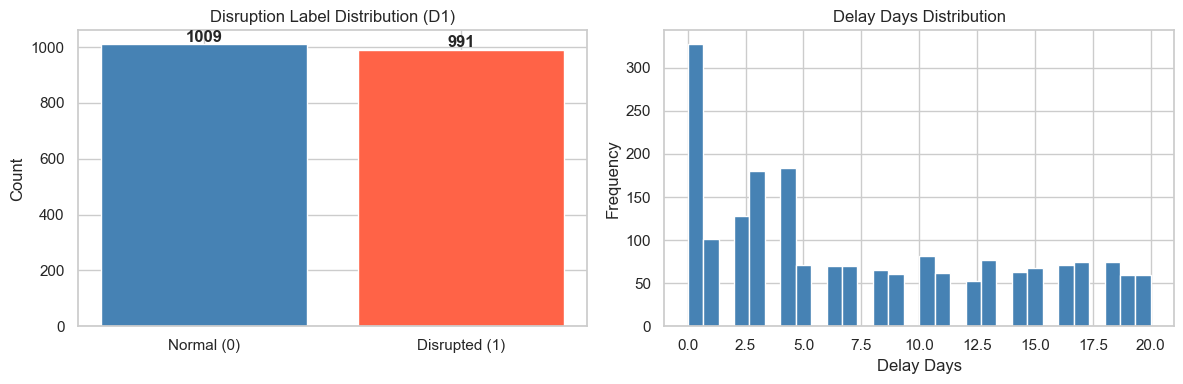

In [7]:
# ── CELL 7: Plot — Disruption Label Distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = d1['disruption_label'].value_counts()
axes[0].bar(['Normal (0)', 'Disrupted (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Disruption Label Distribution (D1)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

d1['delay_days'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Delay Days Distribution')
axes[1].set_xlabel('Delay Days')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

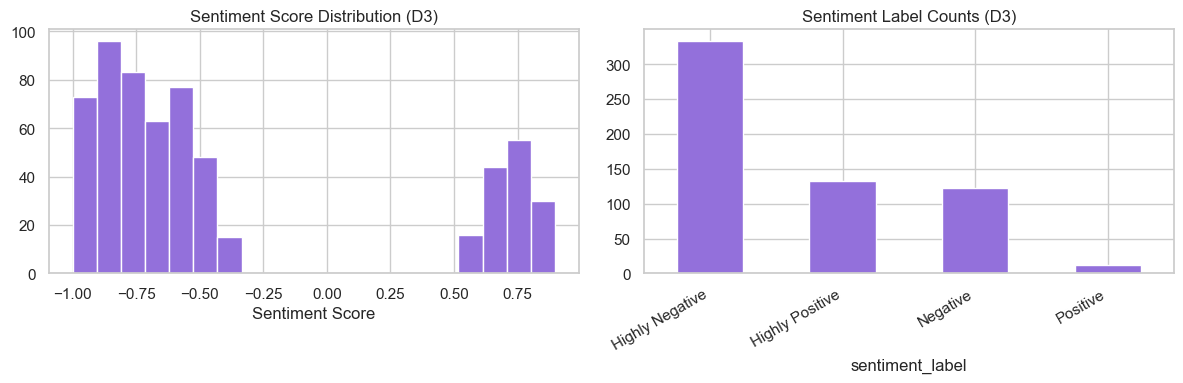

In [8]:
# ── CELL 8: Plot — Sentiment Score Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

d3['sentiment_score'].hist(bins=20, ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Sentiment Score Distribution (D3)')
axes[0].set_xlabel('Sentiment Score')

d3['sentiment_label'].value_counts().plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Sentiment Label Counts (D3)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

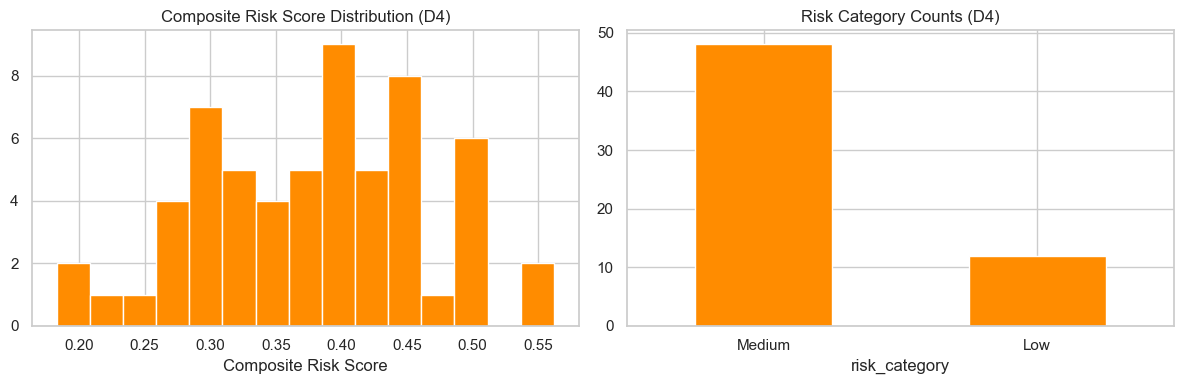

In [9]:
# ── CELL 9: Plot — Composite Risk Score Distribution (D4) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

d4['composite_risk_score'].hist(bins=15, ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('Composite Risk Score Distribution (D4)')
axes[0].set_xlabel('Composite Risk Score')

d4['risk_category'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Risk Category Counts (D4)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

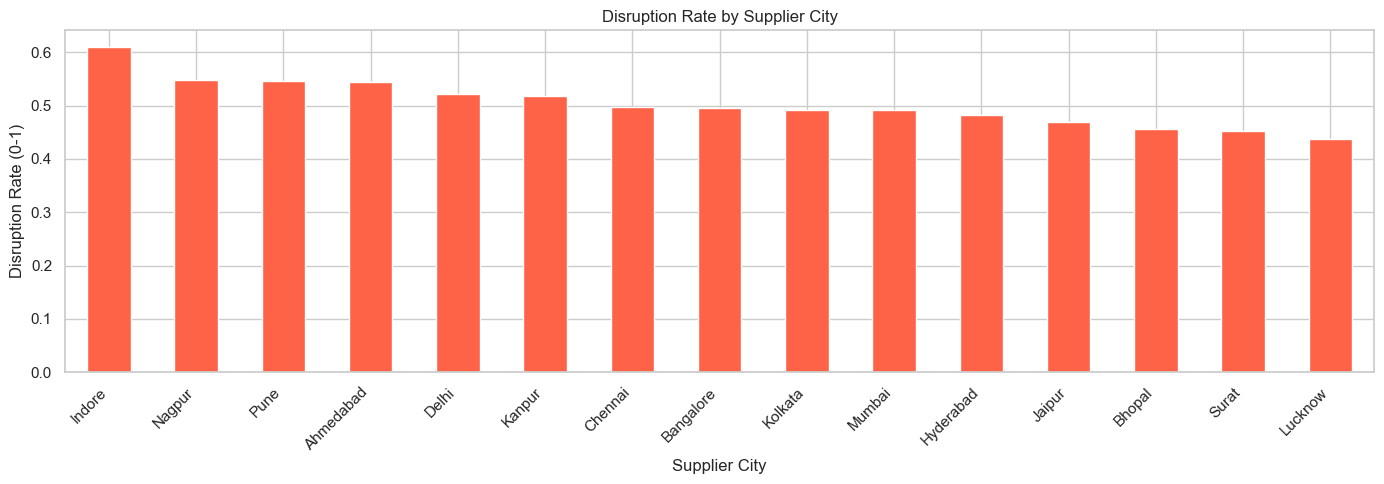

In [10]:
# ── CELL 10: Plot — City-wise Disruption Rate ─────────────────────────────────
city_disruption = d1.groupby('supplier_city')['disruption_label'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
city_disruption.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Disruption Rate by Supplier City')
plt.ylabel('Disruption Rate (0-1)')
plt.xlabel('Supplier City')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

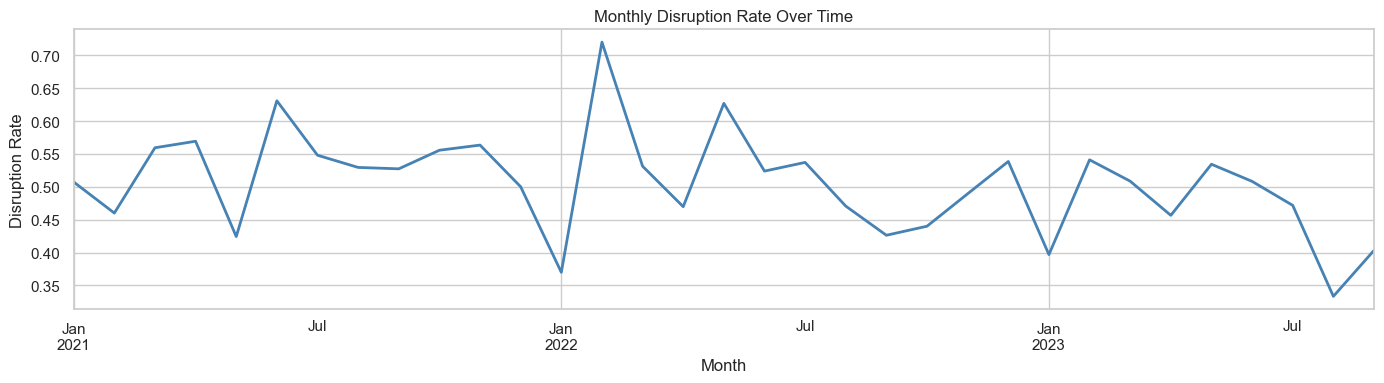

In [11]:
# ── CELL 11: Plot — Monthly Disruption Trend ──────────────────────────────────
d1['year_month'] = d1['order_date'].dt.to_period('M')
monthly = d1.groupby('year_month')['disruption_label'].mean()

plt.figure(figsize=(14, 4))
monthly.plot(color='steelblue', linewidth=2)
plt.title('Monthly Disruption Rate Over Time')
plt.ylabel('Disruption Rate')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

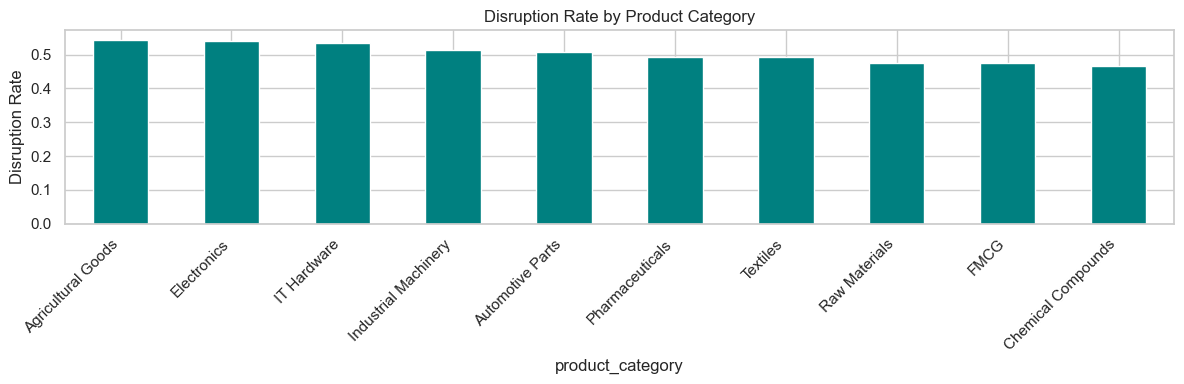

In [12]:
# ── CELL 12: Plot — Product Category vs Disruption Rate ──────────────────────
cat_disruption = d1.groupby('product_category')['disruption_label'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
cat_disruption.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Disruption Rate by Product Category')
plt.ylabel('Disruption Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

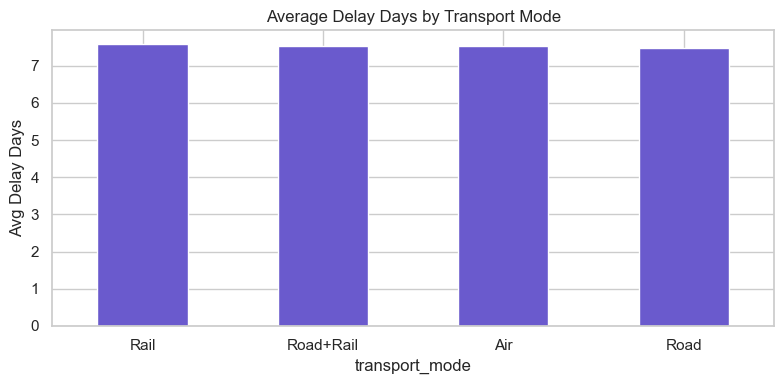

In [13]:
# ── CELL 13: Plot — Transport Mode vs Average Delay ──────────────────────────
mode_delay = d1.groupby('transport_mode')['delay_days'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
mode_delay.plot(kind='bar', color='slateblue', edgecolor='white')
plt.title('Average Delay Days by Transport Mode')
plt.ylabel('Avg Delay Days')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

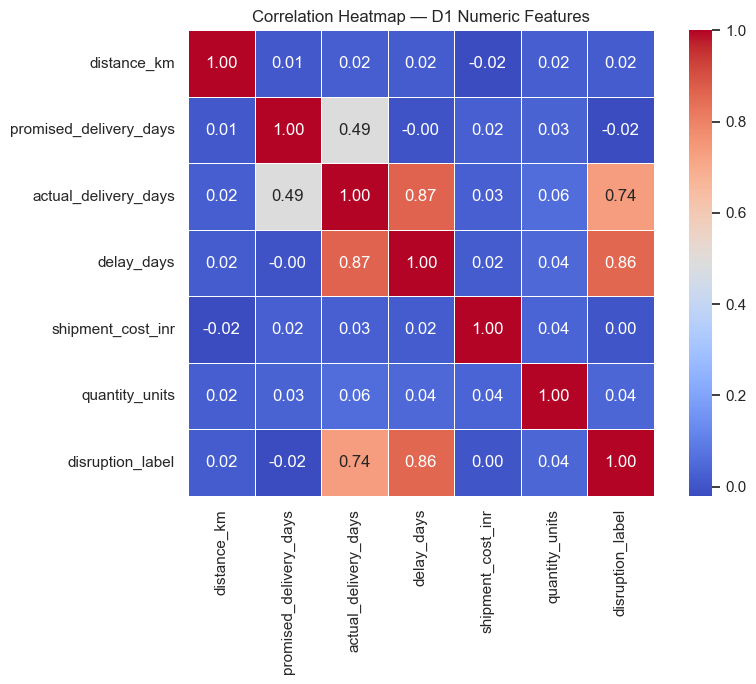

In [14]:
# ── CELL 14: Correlation Heatmap (D1 numeric columns) ─────────────────────────
num_cols = ['distance_km', 'promised_delivery_days', 'actual_delivery_days',
            'delay_days', 'shipment_cost_inr', 'quantity_units', 'disruption_label']

plt.figure(figsize=(9, 7))
sns.heatmap(d1[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — D1 Numeric Features')
plt.tight_layout()
plt.show()

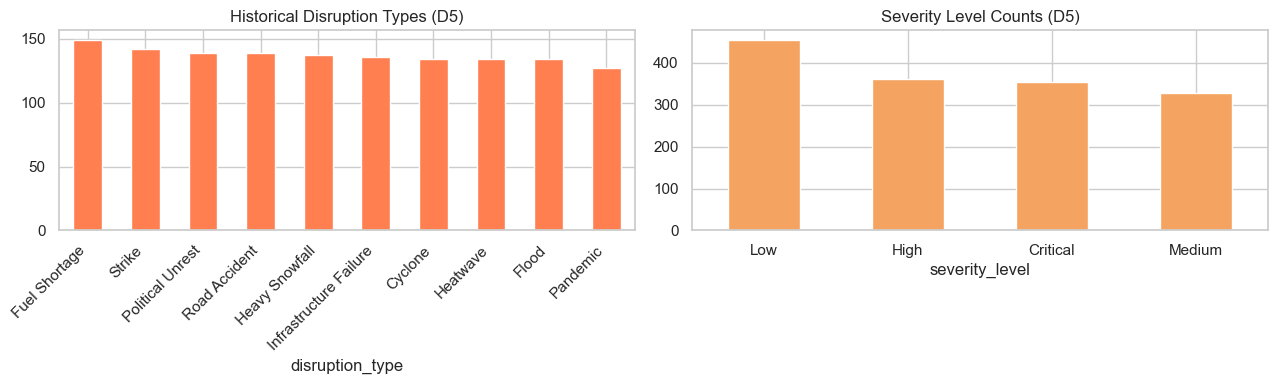


✅ Notebook 1 (EDA) complete.


In [15]:
# ── CELL 15: D5 — Disruption Type Breakdown ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

d5['disruption_type'].value_counts().plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Historical Disruption Types (D5)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

d5['severity_level'].value_counts().plot(kind='bar', ax=axes[1], color='sandybrown', edgecolor='white')
axes[1].set_title('Severity Level Counts (D5)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print('\n✅ Notebook 1 (EDA) complete.')